# HW6: Linear Regression

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd  
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import het_white

from sklearn.datasets import load_boston

In [3]:
%matplotlib inline
%load_ext pycodestyle_magic

In [4]:
def load_housing_data_frame(verbose=True):
    raw = load_boston()
    data_frame = pd.DataFrame(raw.data, columns=raw.feature_names)
    data_frame['PRICE'] = raw.target
    if verbose:
        print(raw.DESCR)
    return data_frame

In [5]:
def plot_cv_results(cv_results, param_x, param_z, metric='mean_test_score'):
    """
    cv_results - cv_results_ attribute of a GridSearchCV instance (or similar)
    param_x - name of grid search parameter to plot on x axis
    param_z - name of grid search parameter to plot by line color
    """
    cv_results = pd.DataFrame(cv_results)
    col_x = 'param_' + param_x
    col_z = 'param_' + param_z
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    sns.pointplot(x=col_x, y=metric, hue=col_z, data=cv_results, ci=99, n_boot=64, ax=ax)
    plt.xticks(rotation=90)
    ax.set_title("CV Grid Search Results")
    ax.set_xlabel(param_x)
    ax.set_ylabel(metric)
    ax.legend(title=param_z)
    return fig

## Loading the data

In [6]:
df = load_housing_data_frame()

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Looking for correlations

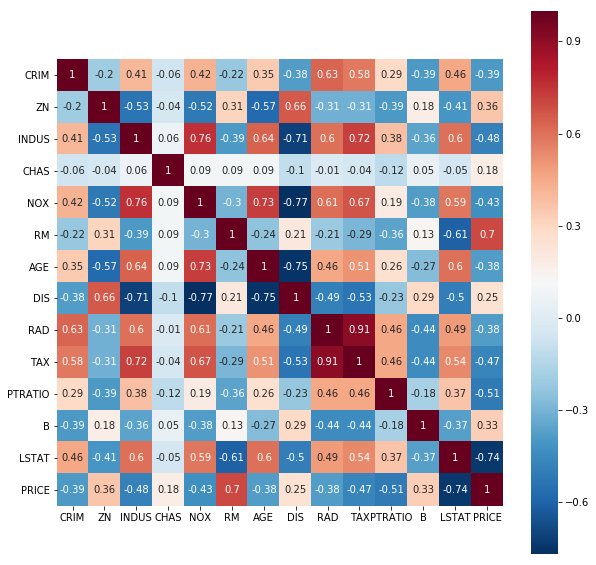

In [8]:
plt.figure(figsize=(10,10))
correlation_matrix = df.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True,
            cmap = 'RdBu_r', square=True)

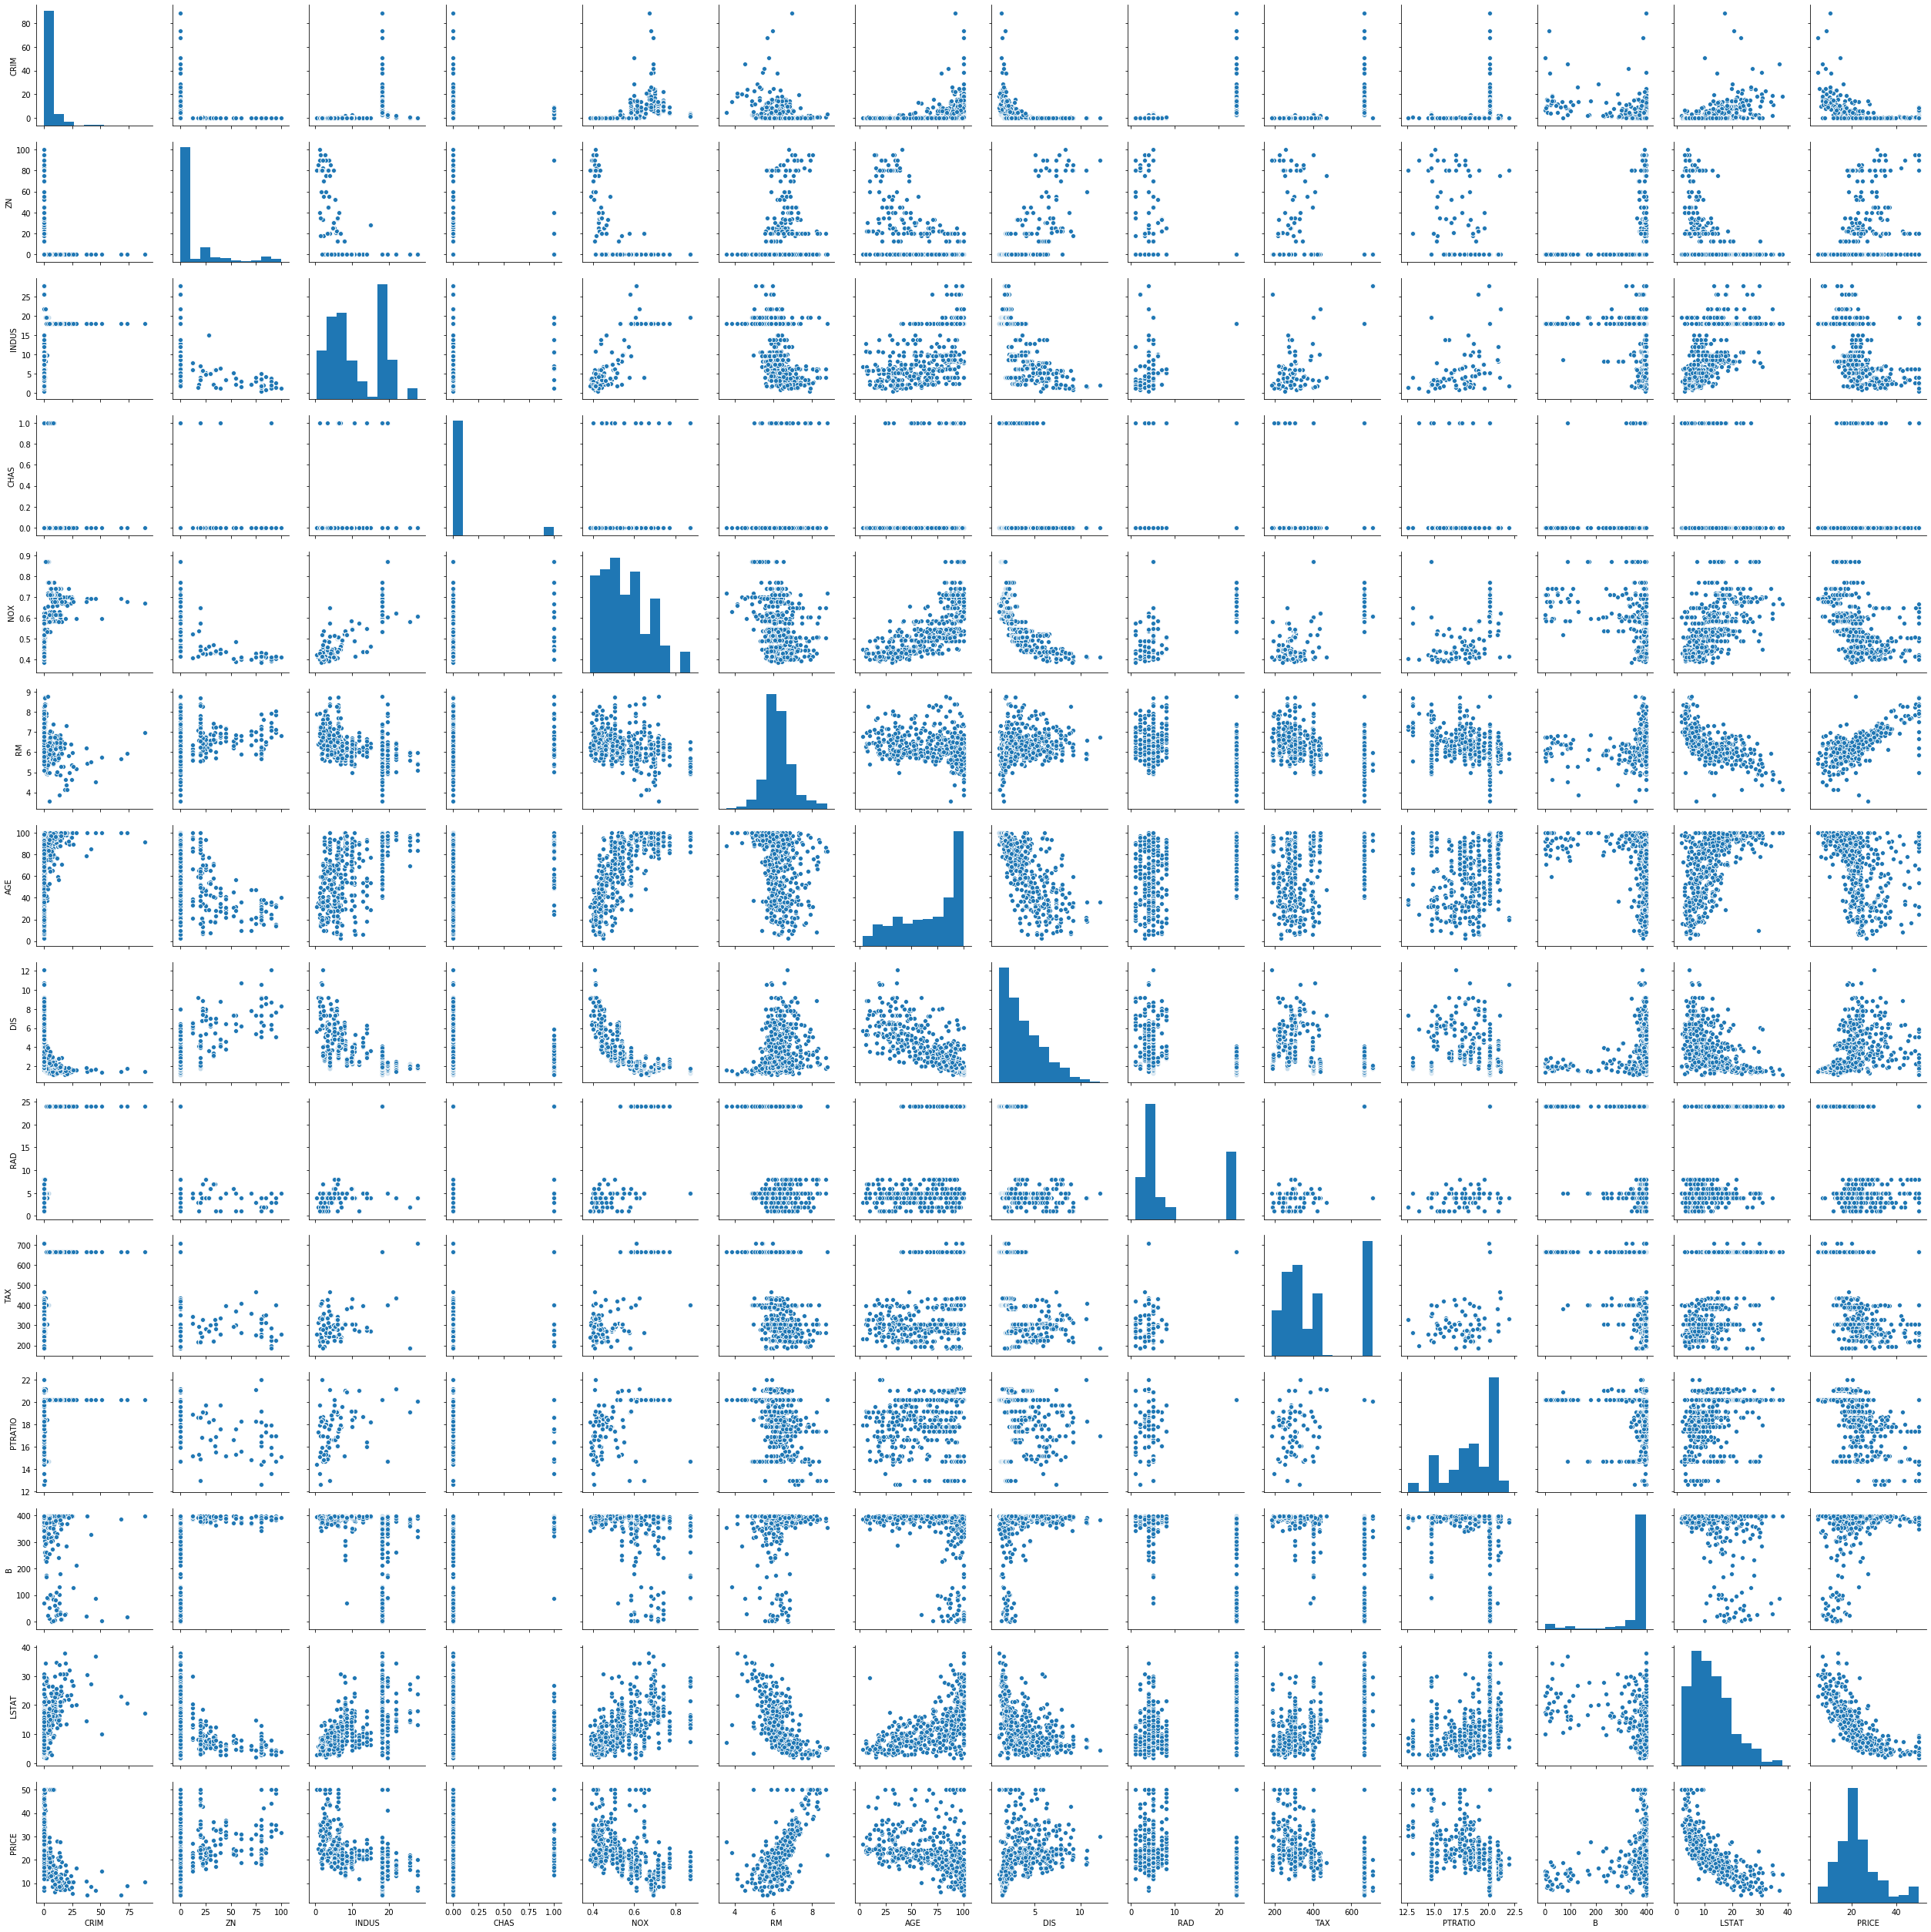

In [9]:
sns.pairplot(df)

## Most promising features

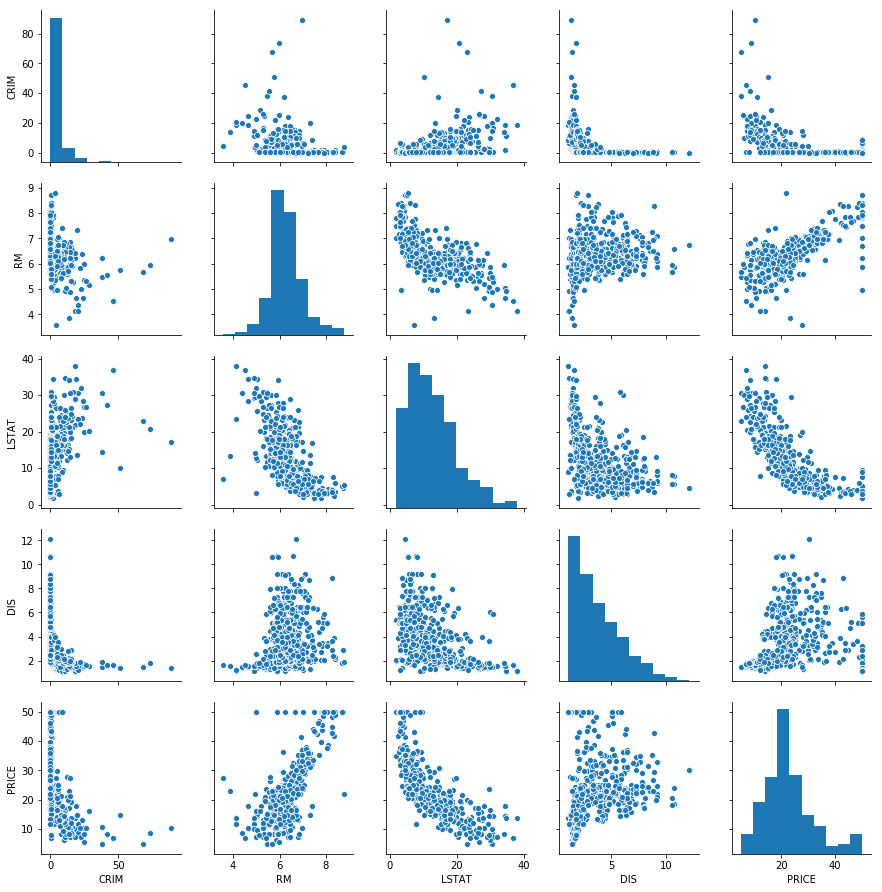

In [197]:
sns.pairplot(df, vars=['CRIM','RM','LSTAT','DIS','PRICE'])

### Taking a logarithm of LSTAT

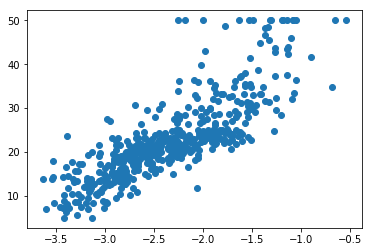

In [198]:
plt.scatter(-np.log(df['LSTAT']), df['PRICE'])

### Trying the same for 'CRIM'

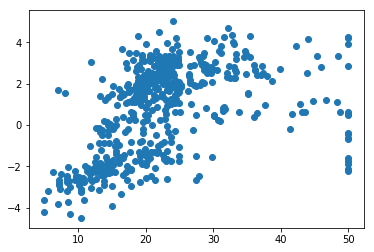

In [199]:
plt.scatter(df['PRICE'], -np.log(df['CRIM']))

## 'DIS'

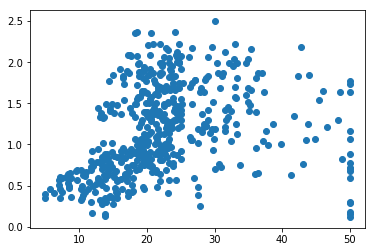

In [200]:
plt.scatter(df['PRICE'], np.log(df['DIS']))

### The graphs don't look promising; however, taking the logarithm increases the correlation coefficient

In [201]:
np.corrcoef(df['PRICE'],-(np.log(df['LSTAT']))) -\
    np.corrcoef(df['PRICE'],(df['LSTAT']))

array([[0.        , 1.55310508],
       [1.55310508, 0.        ]])

In [202]:
np.corrcoef(df['PRICE'],(np.log(df['DIS']))) -\
    np.corrcoef(df['PRICE'],(df['DIS']))

array([[0.00000000e+00, 4.23869365e-02],
       [4.23869365e-02, 2.22044605e-16]])

In [203]:
np.corrcoef(df['PRICE'],-(np.log(df['CRIM']))) -\
    np.corrcoef(df['PRICE'],(df['CRIM']))

array([[ 0.00000000e+00,  8.42606560e-01],
       [ 8.42606560e-01, -2.22044605e-16]])

In [9]:
df['dis_trans'] = np.log(df['DIS'])
df['crim_trans'] = -np.log(df['CRIM'])
df['lstat_trans'] = -np.log(df['LSTAT'])

In [10]:
df = df.drop(['LSTAT','DIS','CRIM'], axis=1)

In [11]:
df.head()

,ZN,INDUS,CHAS,NOX,RM,AGE,RAD,TAX,PTRATIO,B,PRICE,dis_trans,crim_trans,lstat_trans
0,18.0,2.31,0.0,0.538,6.575,65.2,1.0,296.0,15.3,396.90,24.0,1.408545,5.064036,-1.605430
1,0.0,7.07,0.0,0.469,6.421,78.9,2.0,242.0,17.8,396.90,21.6,1.602836,3.600502,-2.212660
2,0.0,7.07,0.0,0.469,7.185,61.1,2.0,242.0,17.8,392.83,34.7,1.602836,3.601235,-1.393766
3,0.0,2.18,0.0,0.458,6.998,45.8,3.0,222.0,18.7,394.63,33.4,1.802073,3.430523,-1.078410
4,0.0,2.18,0.0,0.458,7.147,54.2,3.0,222.0,18.7,396.90,36.2,1.802073,2.672924,-1.673351


In [12]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:, df.columns != 'PRICE'],
                     df.loc[:, 'PRICE'], test_size=0.3,
                     random_state=42)

In [13]:
model = OLS(
    y_train,
    sm.add_constant(X_train)
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     99.99
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          1.36e-107
Time:                        16:43:45   Log-Likelihood:                -1016.1
No. Observations:                 354   AIC:                             2060.
Df Residuals:                     340   BIC:                             2114.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          55.0146      5.982      9.197      

In [14]:
r2_score(y_test, model.predict(sm.add_constant(X_test)))

0.7740459300003464

In [15]:
features = [
    f 
    for f, p in zip([c for c in X_train.columns if c != 'PRICE'],
                    model.pvalues[1:])
    if p < 0.01
]

In [16]:
features

['CHAS', 'NOX', 'RM', 'PTRATIO', 'B', 'dis_trans', 'lstat_trans']

In [17]:
model = OLS(
    y_train,
    sm.add_constant(X_train.loc[:, features])
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     183.9
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          1.64e-112
Time:                        16:44:05   Log-Likelihood:                -1019.9
No. Observations:                 354   AIC:                             2056.
Df Residuals:                     346   BIC:                             2087.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          51.3602      5.618      9.141      

In [18]:
r2_score(y_test, model.predict(sm.add_constant(X_test.loc[:, features])))

0.7591059078446761

## Lasso

In [20]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [21]:
params = {
    'alpha': np.arange(0.03, 0.5, 0.01),
    'selection': ['random']
}

best_lasso = GridSearchCV(
    Lasso(random_state=42, normalize=True), 
    params,
    verbose=True,
    n_jobs=-1,
    cv=5,
    scoring='r2'
)

best_lasso.fit(
    X_train, y_train
)

Fitting 5 folds for each of 47 candidates, totalling 235 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 235 out of 235 | elapsed:    3.2s finished


GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=Lasso(alpha=1.0, copy_X=True, fit_intercept=True,
                             max_iter=1000, normalize=True, positive=False,
                             precompute=False, random_state=42,
                             selection='cyclic', tol=0.0001, warm_start=False),
             iid='warn', n_jobs=-1,
             param_grid={'alpha': array([0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11, 0.12, 0.13,
       0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22, 0.23, 0.24,
       0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33, 0.34, 0.35,
       0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44, 0.45, 0.46,
       0.47, 0.48, 0.49]),
                         'selection': ['random']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='r2', verbose=True)

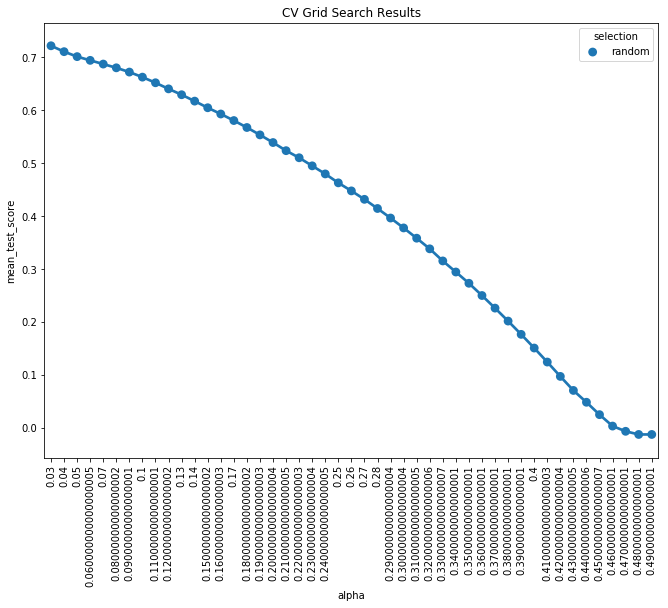

In [22]:
fig = plot_cv_results(best_lasso.cv_results_, 'alpha', 'selection')

In [23]:
best_lasso.best_params_

{'alpha': 0.03, 'selection': 'random'}

In [24]:
best_lasso.best_score_

0.721325791334766

In [25]:
r2_score(best_lasso.best_estimator_.predict(X_test), y_test)

0.5638238221833887

### Looking for the features to exclude

In [26]:
coefs = []
for f, c in zip([c for c in df.columns if c != 'PRICE'],
                best_lasso.best_estimator_.coef_):
    coefs.append((f, c))

coefs.append(('const', best_lasso.best_estimator_.intercept_))

for name, val in sorted(coefs, key=lambda x: abs(x[1]), reverse=True):
    print(f'{name}: {val}')

const: 35.948271283939576
lstat_trans: 8.84734173802334
RM: 2.658449006952925
CHAS: 1.6008677091914172
dis_trans: -0.5733705007414763
PTRATIO: -0.5571837976613082
B: 0.004948092551335308
ZN: -0.0
INDUS: -0.0
NOX: -0.0
AGE: 0.0
RAD: -0.0
TAX: -0.0
crim_trans: 0.0


Non-zero coefficients

In [27]:
nzcoefs = [c[0] for c in coefs if (c[1] != 0) & (c[0] != 'const')]

In [28]:
X_corr_train = X_train.loc[:, nzcoefs]
X_corr_test = X_test.loc[:, nzcoefs]

### Testing with sm

In [29]:
model = OLS(
    y_train,
    sm.add_constant(X_corr_train)
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     201.9
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          6.26e-110
Time:                        16:45:42   Log-Likelihood:                -1028.7
No. Observations:                 354   AIC:                             2071.
Df Residuals:                     347   BIC:                             2099.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          39.4508      4.974      7.932      

### At least the condition number is somewhat lower

In [30]:
r2_score(y_test, model.predict(sm.add_constant(X_corr_test)))

0.730800812846791

### Removing features with high p-values

In [31]:
features = [
    f 
    for f, p in zip([c for c in X_corr_train.columns if c != 'PRICE'],
                    model.pvalues[1:])
    if p < 0.01
]

In [32]:
features

['CHAS', 'RM', 'PTRATIO', 'B', 'dis_trans', 'lstat_trans']

In [33]:
model = OLS(
    y_train,
    sm.add_constant(X_corr_train.loc[:, features])
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     201.9
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          6.26e-110
Time:                        16:46:07   Log-Likelihood:                -1028.7
No. Observations:                 354   AIC:                             2071.
Df Residuals:                     347   BIC:                             2099.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          39.4508      4.974      7.932      

In [34]:
r2_score(y_test, model.predict(sm.add_constant(X_corr_test.loc[:, features])))

0.730800812846791

Doesn't improve anything

## Ridge regression

In [35]:
from sklearn.linear_model import Ridge

params = {
    'alpha': np.arange(0.001, 0.1, 0.005),
    'solver':['auto']
}

best_ridge = GridSearchCV(
    Ridge(random_state=42, normalize=True), 
    params,
    verbose=True,
    n_jobs=1,
    cv=5,
    scoring='r2'
)

best_ridge.fit(
    X_train,y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.4s finished


GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=Ridge(alpha=1.0, copy_X=True, fit_intercept=True,
                             max_iter=None, normalize=True, random_state=42,
                             solver='auto', tol=0.001),
             iid='warn', n_jobs=1,
             param_grid={'alpha': array([0.001, 0.006, 0.011, 0.016, 0.021, 0.026, 0.031, 0.036, 0.041,
       0.046, 0.051, 0.056, 0.061, 0.066, 0.071, 0.076, 0.081, 0.086,
       0.091, 0.096]),
                         'solver': ['auto']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='r2', verbose=True)

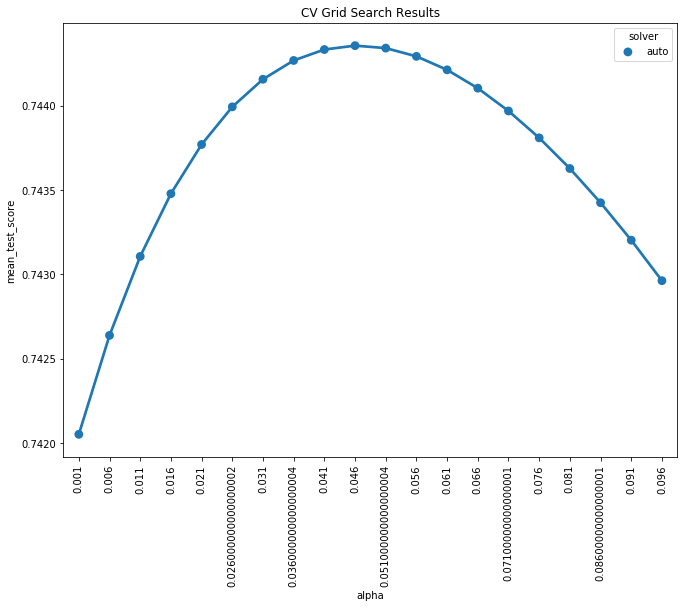

In [36]:
fig = plot_cv_results(best_ridge.cv_results_, 'alpha', 'solver')

In [37]:
print(best_ridge.best_params_)
print('R^2 :', best_ridge.best_score_)

{'alpha': 0.046, 'solver': 'auto'}
R^2 : 0.7443549780871103


In [38]:
r2_score(best_ridge.best_estimator_.predict(X_test), y_test)

0.697666458664117